<a href="https://colab.research.google.com/github/k-randl/conformal_prompting/blob/main/demo/cicle_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Saving prompting resources with CICLe 

In this tutorial, we show how to reduce the cost of few-shot text classification with CICLe, a method introduced in our paper "[CICLe: Conformal In-Context Learning for Largescale Multi-Class Food Risk Classification](https://doi.org/10.18653/v1/2024.findings-acl.459)."

CICLe is a framework that optimizes the way we use LLMs for large-scale, multi-class classification tasks. It combines the power of Conformal Prediction (CP) with in-context learning, allowing the system to make accurate predictions with fewer resources than would be necessary for native few-shot classification. The main idea is to reduce the size of the prompts given to the LLM without losing classification accuracy.

## 1. Theory

CICLe works by involving a base classifier, like a Logistic Regression model, that makes an initial prediction. If the classifier is confident, only a small, relevant set of classes is passed on to the LLM for further refinement. This interaction helps reduce the need to process massive amounts of data, which in turn saves computational power.
Moreover, CICLe uses Conformal Prediction to ensure that the true class is likely included in this shortlist, helping to maintain high accuracy even with fewer class examples in the prompt.

**The benefits of CICLe are twofold:**

- Improved Efficiency: CICLe reduces the computational load by trimming down the size of prompts sent to the LLM, saving time and energy while retaining accuracy.
- Better Handling of Low-Support Classes: CICLe shines in complex tasks with a mix of high-support (that have lots of training examples) and low-support classes (that have very few training examples) where traditional machine learning models typically struggle.

**The general method of CICLe is described in the following graphic:**

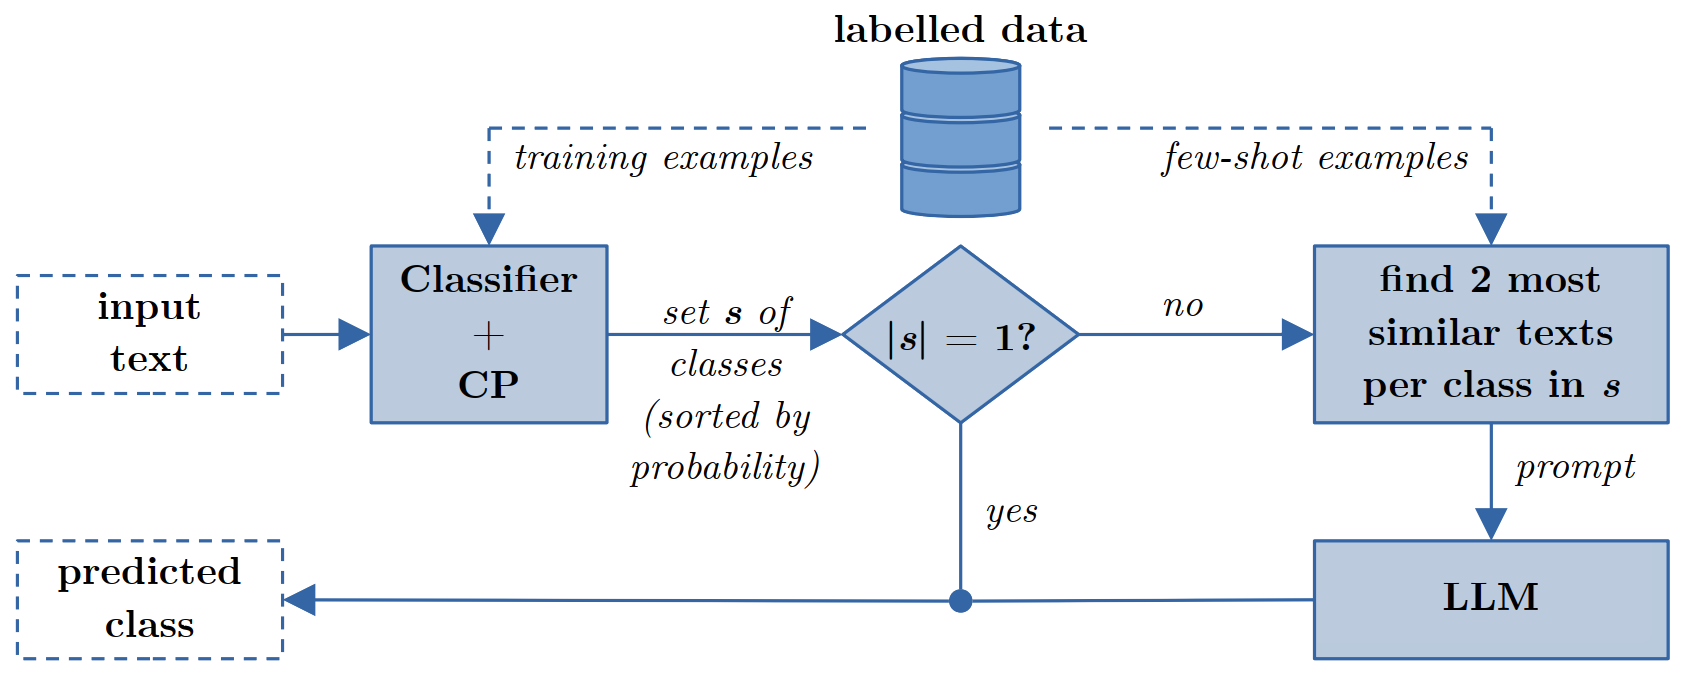

We first classify each text with a simple (weak) classifier. This classifier is enhanced with Conformal Prediction and therefore returns sets of classes that contain the true class of the text with the probability $p=(1-\alpha)$ ($\alpha$ is a parameter chosen by the user). The size of these sets increases with the classifier's uncertainty of the assessed text and has a minimum of 1.
If the set contains only one class (as the base classifier is very certain) we can directly predict that class.
If the set size is greater than 1, we use few-shot prompting with an LLM to find the right one: for each class in the predicted set, we find the most similar texts from our labelled training data to build a few-shot prompt. 

## 2. Implementation

Now that we know what it is all about, let's go through how to set it up step by step!

### Prerequisites:

Before we dive into the implementation, we have to install some prerequisistes:

 - we use [pandas](https://pandas.pydata.org/docs/) to easily load and format our data
 - we use the [crepes](https://github.com/henrikbostrom/crepes) library together with [scikit-learn](https://scikit-learn.org/stable/api/index.html) to implement our conformal base classifier
 - we use Mistral's open source LLM [Mistral 7B-Instruct-v0.3](https://huggingface.co/mistralai/Mistral-7B-Instruct-v0.3) for prompting

 - All experiments will be performed on the [Go Emotions Dataset](https://huggingface.co/datasets/google-research-datasets/go_emotions).

In [1]:
%%capture
# install dependecies:
!pip install numpy matplotlib seaborn torch pandas scikit-learn crepes transformers accelerate tqdm

### Prepare data

Let's start with importing the pandas library and loading data using `load_dataset` and converting them into a pandas `DataFrame`, using the first column as the index (index_col=0). Finally, we use the `.sample()` method to randomly select and display one row from the dataset.

In [2]:
from datasets import load_dataset

train_data = load_dataset("go_emotions", "simplified", split="train")
test_data = load_dataset("go_emotions", "simplified", split="test")

print(f"Train set size: {len(train_data)} examples")
print(f"Test set size: {len(test_data)} examples")

Train set size: 43410 examples
Test set size: 5427 examples


In [3]:
# filter to keep only single-label examples:
def is_single_label(example):
    return len(example["labels"]) == 1

train_data = train_data.filter(is_single_label)
test_data = test_data.filter(is_single_label)

# flatten the label from list to scalar:
def flatten_label(example):
    example["label"] = example["labels"][0]
    return example

train_data = train_data.map(flatten_label)
test_data = test_data.map(flatten_label)

print(f"Train set size: {len(train_data)} examples")
print(f"Test set size: {len(test_data)} examples")

Train set size: 36308 examples
Test set size: 4590 examples


In [4]:
# get the label names:
label_names = train_data.features['labels'].feature.names

# create a mapping from index to label:
index2label = {i: name for i, name in enumerate(label_names)}

In [5]:
# convert datasets to dataframes:
train_df = train_data.to_pandas()
test_df = test_data.to_pandas()

train_df.sample()

,text,labels,id,label
33095,It definitely revealed how ugly the hatred on ...,[3],eetn5g9,3


In [6]:
from sklearn.model_selection import train_test_split

# sample 2k training examples stratified by label:
train_df, _ = train_test_split(
    train_df, stratify=train_df["label"], train_size=2000, random_state=42
)

# sample 1k test examples stratified by label:
test_df, _ = train_test_split(
    test_df, stratify=test_df["label"], train_size=1000, random_state=42
)

# create the development set:
train_df, dev_df = train_test_split(
    train_df, stratify=train_df["label"], test_size=0.2, shuffle=True, random_state=42
)

print(f"Train subset size: {len(train_df)} examples")
print(f"Dev subset size: {len(dev_df)} examples")
print(f"Test subset size: {len(test_df)} examples")

Train subset size: 1600 examples
Dev subset size: 400 examples
Test subset size: 1000 examples


We use the `label` associated with each news `text` as the target category to predict:

In [7]:
# map numeric labels to string labels:
train_df['label'] = train_df['label'].map(index2label)
dev_df['label'] = dev_df['label'].map(index2label)
test_df['label'] = test_df['label'].map(index2label)

In [8]:
# select input and label from data:
X_train = train_df['text'].to_numpy()
y_train = train_df['label'].to_numpy()

X_dev = dev_df['text'].to_numpy()
y_dev = dev_df['label'].to_numpy()

X_test = test_df['text'].to_numpy()
y_test = test_df['label'].to_numpy()

classes = set(y_train)
print('Classes: ', len(classes))

Classes:  28


### Train base classifier

We import TfidfVectorizer from `sklearn.feature_extraction.text` and use it to create and fit a TF-IDF input embedding on the `X_train` data. Since `TfidfVectorizer.transform(...)` returns a sparse matrix, which is incompatible with 'crepes', we define a utility function (`phi`) to convert the sparse matrix into a dense array using `.toarray()`.

In [9]:
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np

# load Contriever model
tokenizer = AutoTokenizer.from_pretrained("facebook/contriever")
model = AutoModel.from_pretrained("facebook/contriever")

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()

# mean pooling function
def mean_pooling(token_embeddings, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return (token_embeddings * mask).sum(1) / mask.sum(1)

# define embedding function (batched to avoid OOM):
def phi(texts, batch_size=32):
    if hasattr(texts, "tolist"):
        texts = texts.tolist()
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            return_tensors="pt",
            max_length=512
        ).to(device)
        with torch.no_grad():
            outputs = model(**inputs)
        embeddings = mean_pooling(outputs.last_hidden_state, inputs["attention_mask"])
        all_embeddings.append(embeddings.cpu().numpy())
    return np.vstack(all_embeddings)
# test embedding shape
phi(X_train[:2].tolist()).shape

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: facebook/contriever
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


(2, 768)

Now let's create a list of unique labels (`id2label`) from the training labels `y_train`. We then build a dictionary (`label2id`) that maps each label to a unique ID using enumeration. Finally, we display the label-to-ID mapping by printing `label2id`.

In [10]:
import numpy as np

# create label to one-hot and reverse dictionaries:
id2label = np.unique(y_train)
label2id = {l:i for i, l in enumerate(id2label)}

# show label-id mapping:
label2id

{'admiration': 0,
 'amusement': 1,
 'anger': 2,
 'annoyance': 3,
 'approval': 4,
 'caring': 5,
 'confusion': 6,
 'curiosity': 7,
 'desire': 8,
 'disappointment': 9,
 'disapproval': 10,
 'disgust': 11,
 'embarrassment': 12,
 'excitement': 13,
 'fear': 14,
 'gratitude': 15,
 'grief': 16,
 'joy': 17,
 'love': 18,
 'nervousness': 19,
 'neutral': 20,
 'optimism': 21,
 'pride': 22,
 'realization': 23,
 'relief': 24,
 'remorse': 25,
 'sadness': 26,
 'surprise': 27}

Now let's train our conformal base classifier! In this tutorial we use the `WrapClassifier` class from `crepes` and the `LogisticRegression` class from `sklearn.linear_model`. First, we create a conformal classifier (`base_classifier`) by wrapping a `LogisticRegression` model.

Next, we train the classifier using the transformed training data (`phi(X_train)`) and the corresponding labels (`label2id[y_train]`).

Finally, we calibrate the classifier on the development set (`phi(X_dev)`) with the corresponding labels, using class-conditional calibration (`class_cond=True`).

In [11]:
from crepes import WrapClassifier
from sklearn.linear_model import LogisticRegression

# create a conformal base classifier based on Logistic Regression:
base_classifier = WrapClassifier(LogisticRegression())

# train the base classifier:
X_train_emb = phi(X_train)
base_classifier.fit(
    X_train_emb,
    [label2id[y] for y in y_train]
)

# calibrate the base classifier:
base_classifier.calibrate(
    phi(X_dev),
    [label2id[y] for y in y_dev],
    class_cond=True
)

WrapClassifier(learner=LogisticRegression(), calibrated=True, predictor=ConformalClassifier(fitted=True, mondrian=True))

In [12]:
import gc

# pre-compute test embeddings before loading LLM:
print("Pre-computing test embeddings...")
X_test_emb = phi(X_test)
print(f"X_train_emb: {X_train_emb.shape}, X_test_emb: {X_test_emb.shape}")

# free Contriever from GPU to make room for LLM:
del model, tokenizer
gc.collect()
torch.cuda.empty_cache()
print("Contriever freed from GPU memory.")

Pre-computing test embeddings...


X_train_emb: (1600, 768), X_test_emb: (1000, 768)


Contriever freed from GPU memory.


### Instantiate Mistral

In order to be able to use huggingface's Mistral models, we first need to log in to huggingface (you can request access to the model [here](https://huggingface.co/mistralai/Mistral-7B-v0.3)).

In [13]:
# import getpass
# from huggingface_hub import login
# login(getpass.getpass('Enter your huggingface API-key:'))

In this tutorial we will use the standard huggingface text-generation pipeline (compressed to 16 bit floating point weights) for the instruction tuned 7B parameter version of Mistral.

In [14]:
import transformers
import torch

# create llm pipeline:
llm = transformers.pipeline(
    "text-generation",
    model="mistralai/Mistral-7B-Instruct-v0.3",
    model_kwargs={"torch_dtype": torch.bfloat16},
    device_map="auto"
)

# Get special tokens for later:
bos_token_id = llm.tokenizer.bos_token_id
eos_token_id = llm.tokenizer.eos_token_id
pad_token_id = llm.tokenizer.pad_token_id or llm.tokenizer.eos_token_id

`torch_dtype` is deprecated! Use `dtype` instead!


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

### Results Handling Helper

In [15]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import json

def save_results(y_true, y_pred, classes, filename="results.json"):
    """
    Save classification metrics (report, accuracy, confusion matrix) to JSON.

    Args:
        y_true: Ground truth labels
        y_pred: Predicted labels
        classes: List of all class labels (keeps consistent ordering)
        filename: Output JSON filename
    """
    report = classification_report(
        y_true, y_pred, labels=classes, zero_division=0, output_dict=True
    )
    accuracy = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=classes)

    results = {
        "classification_report": report,
        "accuracy": accuracy,
        "confusion_matrix": cm.tolist(),
        "labels": classes 
    }

    with open(filename, "w") as f:
        json.dump(results, f, indent=2)

    print(f"Results saved to: '{filename}'")

In [16]:
import json
import numpy as np

def save_prompt_lengths(prompt_lengths, input_lengths, shots_lengths, num_shots, filename="prompt_lengths.json"):
    """
    Save prompt, input, shots section lengths, and number of shots to a JSON file, 
    including summary statistics.

    Args:
        prompt_lengths: List of total prompt token counts.
        input_lengths: List of input (test text) token counts.
        shots_lengths: List of few-shot section token counts.
        num_shots: List of number of few-shot examples per prompt.
        filename: Output JSON filename.
    """
    stats = {
        "prompt_lengths": {
            "mean": float(np.mean(prompt_lengths)),
            "min": int(np.min(prompt_lengths)),
            "max": int(np.max(prompt_lengths)),
            "std": float(np.std(prompt_lengths)),
            "values": prompt_lengths
        },
        "input_lengths": {
            "mean": float(np.mean(input_lengths)),
            "min": int(np.min(input_lengths)),
            "max": int(np.max(input_lengths)),
            "std": float(np.std(input_lengths)),
            "values": input_lengths
        },
        "shots_lengths": {
            "mean": float(np.mean(shots_lengths)),
            "min": int(np.min(shots_lengths)),
            "max": int(np.max(shots_lengths)),
            "std": float(np.std(shots_lengths)),
            "values": shots_lengths
        },
        "num_shots": {
            "mean": float(np.mean(num_shots)),
            "min": int(np.min(num_shots)),
            "max": int(np.max(num_shots)),
            "std": float(np.std(num_shots)),
            "values": num_shots
        }
    }

    with open(filename, "w") as f:
        json.dump(stats, f, indent=2)

    print(f"Prompt length statistics saved to: '{filename}'")

### CICLe

The main part of the CICLe functionality is implemented in the following function `get_fixed_k_examples`. It takes a given `text`, a set of predictions (`prediction_set`) created by assessing `text` with our conformal classifier, and an optional number of examples (`k`, default 2). It identifies and returns the globally k most similar training examples from classes in the prediction set.

1. We restrict the training set to examples belonging to classes in the prediction set.
2. We compute cosine similarity between the test embedding and these training embeddings.
3. The k closest training examples are selected globally (not per-class) and returned sorted by descending similarity.

In [17]:
from sklearn.metrics import pairwise_distances

def get_fixed_k_examples(test_idx, prediction_set, k=2):
    """
    Return exactly k training examples with highest cosine similarity to X_test[test_idx],
    selected globally from classes in the prediction_set.
    Returns list of (text, label, similarity) tuples sorted by descending similarity.
    """
    test_emb = X_test_emb[test_idx:test_idx+1]
    mask = np.isin(y_train, list(prediction_set))
    if not mask.any():
        return []
    train_embs_masked = X_train_emb[mask]
    y_train_masked = y_train[mask]
    X_train_masked = X_train[mask]
    similarity = (1. - pairwise_distances(test_emb, train_embs_masked, metric='cosine'))[0]
    top_k_idx = np.argsort(similarity)[::-1][:k]
    return [(X_train_masked[i], y_train_masked[i], similarity[i]) for i in top_k_idx]

In [18]:
# print sample output:
samples = get_fixed_k_examples(
    0,
    id2label[base_classifier.predict_set(X_test_emb[:1], confidence=0.95).astype(bool)[0]],
    k=2
)
samples

[('is [NAME] playing?', 'neutral', np.float32(0.6007534)),
 ('That was [NAME] not [NAME]', 'neutral', np.float32(0.591218))]

The `create_prompt` function generates a formatted prompt for classification tasks using a given text and labeled examples.

1. The function creates a context string, which introduces the task and includes labeled examples provided in the examples list, sorted by probability.
2. Each example is appended to the context in the format `"<example text>" => <class label>` (hence we need to use a helper function, `replace_qm`, to replace double quotes (`"`) with single quotes (`'`) in the text).
3. Finally, it returns a dictionary formatted for a user prompt, asking to predict the class label for the input text, which is also cleaned of double quotes.

In [19]:
def create_prompt(text, examples):
    # helper function replacing quotation marks in the text:
    replace_qm = lambda s: s.replace('"', "'")

    # create context:
    context = f'We classify user questions into topic categories based on their text. Here are some labelled examples sorted from most probable to least probable:\n'

    for x, y, _ in examples:
        context += f'\n"{replace_qm(x)}" => {y}'

    return {"role": "user", "content": f'{context}\n\nPlease predict the correct class for the following sample. Only provide the class label.\n\n"{replace_qm(text)}" => '}

# print sample prompt:
print(create_prompt(X_test[0], samples)["content"])

We classify user questions into topic categories based on their text. Here are some labelled examples sorted from most probable to least probable:

"is [NAME] playing?" => neutral
"That was [NAME] not [NAME]" => neutral

Please predict the correct class for the following sample. Only provide the class label.

"In what ways has [NAME] out-coached [NAME]? I see this all the time and yet never any examples." => 


Now it's time to calculate the conformal prediction sets for our test data:

In [20]:
# calculate prediction sets:
ps_test = [id2label[s.astype(bool)] for s in base_classifier.predict_set(X_test_emb, confidence=0.95)]

Finally, we put all pieces together to predict labels for the test set (`X_test`) using CICLe.

1. For each text (`x`) in X_test and its associated prediction set (`ps`), the function `get_fixed_k_examples` retrieves two of the most similar training examples.
2. If at least two examples are found, a prompt is created using `create_prompt()`.
3. The LLM is then used to predict the class label based on this prompt, and the result is added to the predictions list.
4. If there is only one class in the prediction set, it is directly used as the prediction.

In [21]:
from tqdm import tqdm

# predict test set:
predictions = []
for i, (x, ps) in tqdm(enumerate(zip(X_test, ps_test)), total=len(X_test), desc='Assessing texts'):
    if len(ps) > 1:
        # get 4 most similar texts in the training data:
        examples = get_fixed_k_examples(i, ps, k=4)

        # create prompt:
        prompt = create_prompt(x, examples)

        # prompt LLM:
        predictions.append(llm([prompt],
            bos_token_id=bos_token_id,
            eos_token_id=eos_token_id,
            pad_token_id=pad_token_id,
            max_new_tokens=5,
            do_sample=False,
            temperature=None,
            top_p=None
        )[0]["generated_text"][-1]["content"].strip())

    else: predictions.append('Other')

Assessing texts:   0%|          | 0/1000 [00:00<?, ?it/s]

Passing `generation_config` together with generation-related arguments=({'top_p', 'temperature', 'pad_token_id', 'do_sample', 'eos_token_id', 'max_new_tokens', 'bos_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Assessing texts:   0%|          | 1/1000 [00:00<08:25,  1.98it/s]

Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Assessing texts: 100%|█████████▉| 998/1000 [01:53<00:00,  8.20it/s]

Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Assessing texts: 100%|█████████▉| 999/1000 [01:54<00:00,  7.71it/s]

Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Assessing texts: 100%|██████████| 1000/1000 [01:54<00:00,  8.76it/s]

Classification Report:
                 precision    recall  f1-score   support

       sadness       0.40      0.45      0.43        22
    admiration       0.42      0.43      0.43        76
         anger       0.24      0.52      0.33        29
   realization       0.04      0.05      0.05        19
       disgust       0.35      0.35      0.35        17
 embarrassment       0.29      0.40      0.33         5
          fear       0.33      0.29      0.31        14
      approval       0.19      0.24      0.21        51
        relief       0.00      0.00      0.00         2
      optimism       0.46      0.26      0.33        23
   nervousness       0.00      0.00      0.00         3
     gratitude       0.67      0.61      0.64        57
     annoyance       0.15      0.17      0.16        42
         pride       0.00      0.00      0.00         2
     amusement       0.41      0.63      0.50        41
          love       0.45      0.49      0.47        35
     confusion       0.

Text(0.5, 1.0, 'Confusion Matrix')

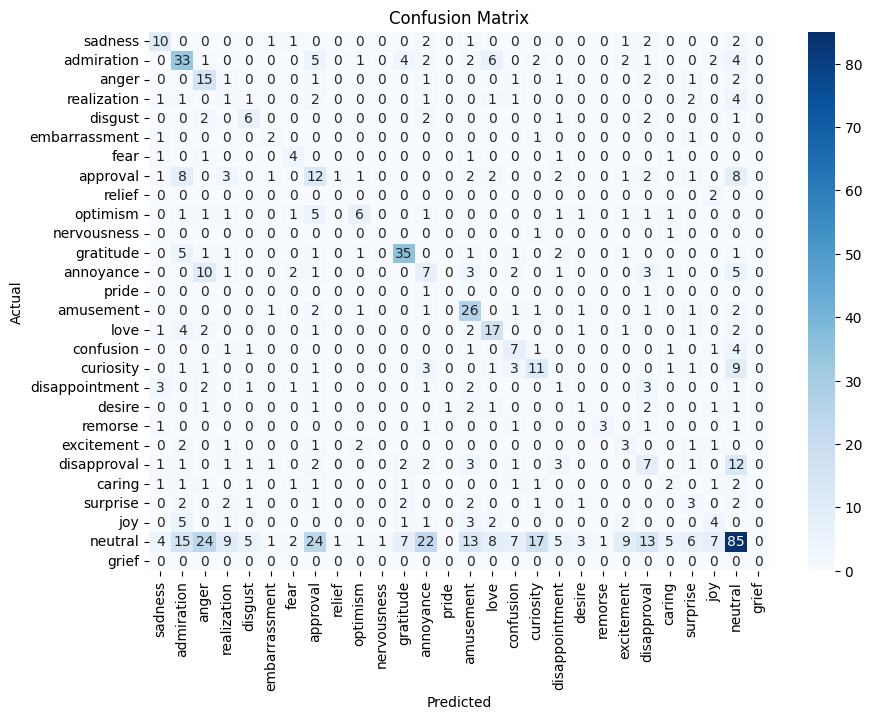

In [22]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Classification Report:\n", classification_report(y_test, predictions, labels=list(classes), zero_division=0))
print("Accuracy:", accuracy_score(y_test, predictions))

# Plot confusion matrix
cm = confusion_matrix(y_test, predictions, labels=list(classes))
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')

In [23]:
from tqdm import tqdm
import numpy as np

prompt_lengths = []
input_lengths = []
shots_lengths = []
num_shots = [] 

for i, (x, ps) in tqdm(enumerate(zip(X_test, ps_test)), total=len(X_test), desc='Calculating token stats'):
    if len(ps) > 1:
        # get the most similar examples
        examples = get_fixed_k_examples(i, ps, k=4)

        # build the prompt (same as before)
        prompt = create_prompt(x, examples)["content"]

        # compute tokenized lengths
        prompt_len = len(llm.tokenizer(prompt)["input_ids"])
        input_len = len(llm.tokenizer(x)["input_ids"])
        # join the examples' text parts for shots length
        shots_text = "\n".join([ex[0] if isinstance(ex, (list, tuple)) else str(ex) for ex in examples])
        shots_len = len(llm.tokenizer(shots_text)["input_ids"])

        prompt_lengths.append(prompt_len)
        input_lengths.append(input_len)
        shots_lengths.append(shots_len)
        num_shots.append(len(examples))

# Print averages
print(f"Average prompt length: {np.mean(prompt_lengths):.1f} tokens")
print(f"Average input length: {np.mean(input_lengths):.1f} tokens")
print(f"Average shots section length: {np.mean(shots_lengths):.1f} tokens")
print(f"Average number of shots: {np.mean(num_shots):.1f}")

Calculating token stats:   0%|          | 0/1000 [00:00<?, ?it/s]

Calculating token stats:   2%|▏         | 22/1000 [00:00<00:04, 214.44it/s]

Calculating token stats:   4%|▍         | 44/1000 [00:00<00:04, 215.86it/s]

Calculating token stats:   7%|▋         | 66/1000 [00:00<00:04, 206.52it/s]

Calculating token stats:   9%|▉         | 89/1000 [00:00<00:04, 212.36it/s]

...

Calculating token stats:  95%|█████████▍| 948/1000 [00:05<00:00, 205.52it/s]

Calculating token stats:  97%|█████████▋| 970/1000 [00:05<00:00, 182.46it/s]

Calculating token stats:  99%|█████████▉| 990/1000 [00:05<00:00, 138.58it/s]

Calculating token stats: 100%|██████████| 1000/1000 [00:05<00:00, 166.71it/s]

Average prompt length: 151.5 tokens
Average input length: 18.4 tokens
Average shots section length: 66.6 tokens
Average number of shots: 4.0


In [24]:
save_results(y_test, predictions, list(classes), filename="/home/v25/ippa6201/cicle-evaluation/go-emotions/results/predictions/go-emotions-mistral-7b-v0.3-cicle-contriever-lr-2.0k-samples-4-shots-fixed-0.05-α.json")

Results saved to: '/home/v25/ippa6201/cicle-evaluation/go-emotions/results/predictions/go-emotions-mistral-7b-v0.3-cicle-contriever-lr-2.0k-samples-4-shots-fixed-0.05-α.json'


In [25]:
save_prompt_lengths(prompt_lengths, input_lengths, shots_lengths, num_shots, filename="/home/v25/ippa6201/cicle-evaluation/go-emotions/results/lengths/go-emotions-mistral-7b-v0.3-cicle-contriever-lr-2.0k-samples-4-shots-fixed-0.05-α.json")

Prompt length statistics saved to: '/home/v25/ippa6201/cicle-evaluation/go-emotions/results/lengths/go-emotions-mistral-7b-v0.3-cicle-contriever-lr-2.0k-samples-4-shots-fixed-0.05-α.json'


In our paper CICLe was tested on food risk classification, a task involving classifying food recall announcements into hundreds of fine-grained categories. In this scenario, CICLe outperformed other models, achieving comparable or better accuracy while drastically cutting down on computational resources.

CICLe shows us that we don’t always need brute force computing to get the best results — sometimes, it’s all about using smarter strategies.